In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

##About this dataset
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."
## About the Attributes
- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

In [ ]:
df=pd.read_csv("TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")

In [ ]:
df.drop(columns=["customerID","gender","PhoneService","OnlineBackup","DeviceProtection","StreamingMovies","PaperlessBilling","TotalCharges"],axis=1,inplace=True)

In [ ]:
df.replace("?",np.nan,inplace=True)

In [ ]:
missing_value_columns=df.columns[df.isnull().any()].tolist()
df[missing_value_columns]

""
0
1
2
3
4
...
7038
7039
7040
7041


In [ ]:
categoric_data=df.select_dtypes(include=["object"])
for column in categoric_data.columns:
    df[column]=LabelEncoder().fit_transform(df[column])

In [ ]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,1,0,0,0,0,0,2,29.85,0
1,0,0,0,34,0,0,2,0,0,1,3,56.95,0
2,0,0,0,2,0,0,2,0,0,0,3,53.85,1
3,0,0,0,45,1,0,2,2,0,1,0,42.30,0
4,0,0,0,2,0,1,0,0,0,0,2,70.70,1


In [ ]:
X=df.drop("Churn",axis=1)
y=df["Churn"]
X.to_numpy()
y.to_numpy()
X=StandardScaler().fit(X).transform(X.astype(float))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=4)

In [ ]:
def plot_confusion_matrix(y,y_pred):
    conf_matrix=confusion_matrix(y,y_pred)
    sns.heatmap(conf_matrix,annot=True,cmap='Blues',fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
model=LogisticRegression(max_iter=1000,class_weight="balanced")
parameters = {"solver": ["liblinear","lbfgs","newton-cg","sag", "saga"],"C": [0.07,0.08,0.09]}
log_cv=GridSearchCV(model,parameters,cv=10)
log_cv.fit(X_train,y_train)
print("best parameters:",log_cv.best_params_)
print("best cv score:", log_cv.best_score_)
best_model=log_cv.best_estimator_
best_model.fit(X_train,y_train)

best parameters: {'C': 0.07, 'solver': 'lbfgs'}
best cv score: 0.7519269776876267


LogisticRegression(C=0.07, class_weight='balanced', max_iter=1000)

In [ ]:
y_hat=best_model.predict(X_test)
accuracy_score(y_test,y_hat)

0.7240889730241363

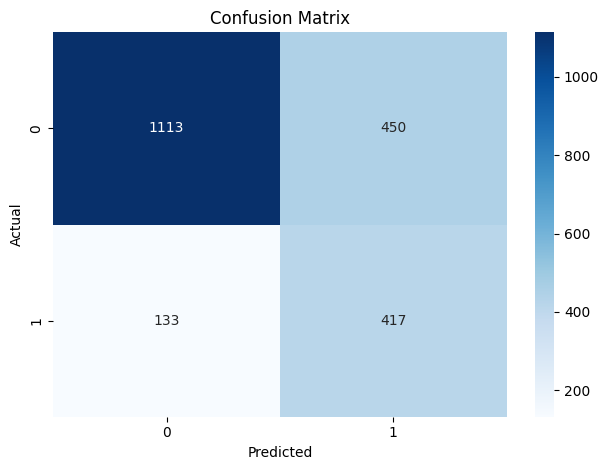

In [ ]:
plot_confusion_matrix(y_test,y_hat)

In [ ]:
model=RandomForestClassifier(random_state=42,class_weight="balanced")
parameters={"n_estimators": [220,225,230],"max_depth": [13,14,15],"min_samples_split": [5,6,7]}
rf_cv = GridSearchCV(model,parameters,cv=5,verbose=2,n_jobs=-1)
rf_cv.fit(X_train, y_train)
print("Final Best Parameters:", rf_cv.best_params_)
print("Best CV Score:", rf_cv.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Final Best Parameters: {'max_depth': 13, 'min_samples_split': 5, 'n_estimators': 225}
Best CV Score: 0.7855983772819473


In [ ]:
best_model = rf_cv.best_estimator_
best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=13,
                       min_samples_split=5, n_estimators=225, random_state=42)

In [ ]:
y_hat = best_model.predict(X_test)
accuracy_score(y_test,y_hat)

0.7638428774254614

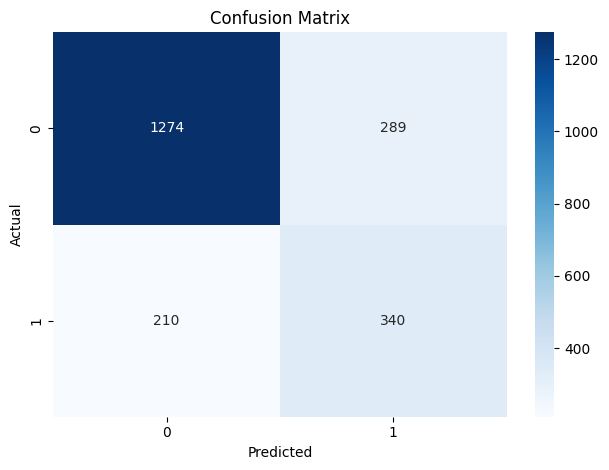

In [ ]:
plot_confusion_matrix(y_test,y_hat)

In [ ]:
model=KNeighborsClassifier()
parameters={"n_neighbors":[1,2,3,4,5],"weights": ["uniform","distance"],
           "metric":['euclidean','manhattan','minkowski']}
kn_cv=GridSearchCV(model,parameters,cv=5,verbose=2,n_jobs=-1)
kn_cv.fit(X_train,y_train)
print("best parameters:", kn_cv.best_params_)
print("best cv score:",kn_cv.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
best parameters: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'uniform'}
best cv score: 0.7782961460446247


In [ ]:
best_model=kn_cv.best_estimator_
best_model.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=4)

In [ ]:
y_hat=best_model.predict(X_test)
accuracy_score(y_test,y_hat)

0.7723615712257453

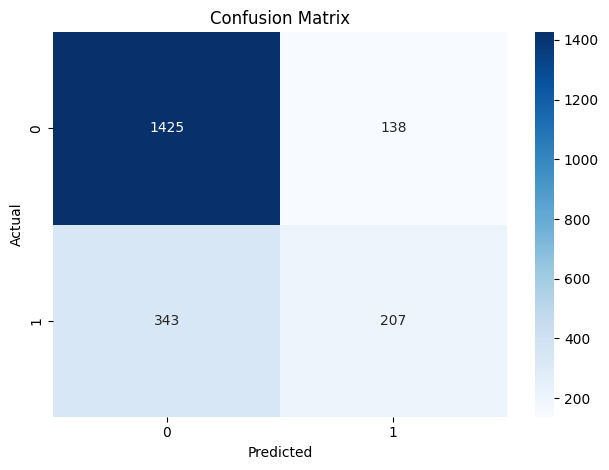

In [ ]:
plot_confusion_matrix(y_test,y_hat)